# Retail Sales and Profitability Analysis Notebook

This notebook analyses the Superstore Orders dataset to understand business performance across customer segments, markets, categories, shipping modes, discounts, and loss-making transactions. It focuses on identifying key profit drivers, areas of profit erosion, and patterns that can support dashboard development and business decision-making.

The notebook includes data inspection, data preparation, exploratory data analysis, feature creation for dashboard use, and summary findings with business recommendations. The People and Returns datasets are briefly inspected for context, but the main analysis and dashboard-ready dataset are based on the Orders dataset.

### Data Source

Dataset: Global Superstore Dataset  
Source: Kaggle  
URL: https://www.kaggle.com/datasets/shekpaul/global-superstore?resource=download

# 1. Import Libraires

In [3]:
#import required libraries
import pandas as pd

In [4]:
pip install xlrd


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 2. Load Dataset

In [9]:
#print the names of the sheets inluded in the file
xls=pd.ExcelFile('../data/raw/Global_Superstore.xls')
print(xls.sheet_names)

['Orders', 'Returns', 'People']


In [11]:
#read each excel sheet
orders=pd.read_excel('../data/raw/Global_Superstore.xls', sheet_name='Orders')
returns=pd.read_excel('../data/raw/Global_Superstore.xls', sheet_name='Returns')
people=pd.read_excel('../data/raw/Global_Superstore.xls', sheet_name='People')

# 3. Initial Data Exploration

## 3.1. Orders Dataset

In [12]:
#inspect the inital rows of the orders dataset
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [13]:
#check column names, data typesm and non-null counts of the orders dataset
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [14]:
#inspect the shape of the dataset
orders.shape

(51290, 24)

In [15]:
#check the num of null values include in each column of the orders dataset
orders.isna().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [16]:
#check the summary statistics of the orders dataset
orders.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818
min,1.00000,2011-01-01 00:00:00,2011-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,12823.25000,2012-06-19 00:00:00,2012-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,2013-07-08 00:00:00,2013-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,2014-05-22 00:00:00,2014-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,2014-12-31 00:00:00,2015-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.29199,NaN,NaN,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296810


In [17]:
#check the num of duplicated rows included in the dataset
orders.duplicated().sum()

np.int64(0)

In [18]:
#check the data types of each column in the dataset
orders.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
City                      object
State                     object
Country                   object
Postal Code              float64
Market                    object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority            object
dtype: object

## 3.2. Returns Dataset

In [19]:
#inspect the inital rows of the returns dataset
returns.head()

,Returned,Order ID,Market
0,Yes,MX-2013-168137,LATAM
1,Yes,US-2011-165316,LATAM
2,Yes,ES-2013-1525878,EU
3,Yes,CA-2013-118311,United States
4,Yes,ES-2011-1276768,EU


In [20]:
#check the count of null values in the returns dataset
returns.isna().sum()

Returned    0
Order ID    0
Market      0
dtype: int64

In [301]:
#check the values include in the 'returned' column
returns['Returned'].unique()

array(['Yes'], dtype=object)

In [302]:
#check the count of returns by market
returns.groupby('Market')['Returned'].agg('count')

Market
APAC             296
EU               284
LATAM            297
United States    296
Name: Returned, dtype: int64

## 3.3. People Dataset

In [21]:
#inspect the intial rows of the people dataset
people.head()

,Person,Region
0,Anna Andreadi,Central
1,Chuck Magee,South
2,Kelly Williams,East
3,Matt Collister,West
4,Deborah Brumfield,Africa


In [23]:
#check the count of null values in the people dataset
people.isna().sum()

Person    0
Region    0
dtype: int64

# 4. Feature Engineering

In [24]:
#create discount range categories
orders['discount_band']=pd.cut(
    orders['Discount'], 
    bins=[-0.1, 0, 0.1, 0.2, 0.3, 0.5, 1], 
    labels=['0', '1-10%', '10-20%', '20-30%', '30-50%', '50%+']
)

In [25]:
#create loss and positive profit columns for dashboard analysis
orders['Loss']=orders['Profit'].apply(lambda x: x if x<0 else 0)
orders['Positive Profit']=orders['Profit'].apply(lambda x: x if x>0 else 0)

In [26]:
#inspect the orders dataset after creating new columns
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row ID           51290 non-null  int64         
 1   Order ID         51290 non-null  object        
 2   Order Date       51290 non-null  datetime64[ns]
 3   Ship Date        51290 non-null  datetime64[ns]
 4   Ship Mode        51290 non-null  object        
 5   Customer ID      51290 non-null  object        
 6   Customer Name    51290 non-null  object        
 7   Segment          51290 non-null  object        
 8   City             51290 non-null  object        
 9   State            51290 non-null  object        
 10  Country          51290 non-null  object        
 11  Postal Code      9994 non-null   float64       
 12  Market           51290 non-null  object        
 13  Region           51290 non-null  object        
 14  Product ID       51290 non-null  objec

In [27]:
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,discount_band,Loss,Positive Profit
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,0,0.000,762.1845
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,1-10%,-288.765,0.0000
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,1-10%,0.000,919.9710
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,1-10%,-96.540,0.0000
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,0,0.000,311.5200


# 5. Exploratory Data Analysis

## 5.1. Segment Analysis

In [29]:
#check the number of unique values included in the 'Segment' column
orders['Segment'].nunique()

3

In [30]:
#check the unique values included in the 'Segment' column
orders['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [31]:
#check the count of each unique segment in the column
orders['Segment'].value_counts()

Segment
Consumer       26518
Corporate      15429
Home Office     9343
Name: count, dtype: int64

In [32]:
#check the profit made the each segment
orders.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

Segment
Consumer       749239.78206
Corporate      441208.32866
Home Office    277009.18056
Name: Profit, dtype: float64

In [33]:
#check the sales and profit made by each segment
orders.groupby('Segment')[['Sales', 'Profit']].sum()

,Sales,Profit
Segment,,
Consumer,6.507949e+06,749239.78206
Corporate,3.824698e+06,441208.32866
Home Office,2.309855e+06,277009.18056


In [34]:
#check the average profit made by each segment
orders.groupby('Segment')['Profit'].mean().sort_values(ascending=False)

Segment
Home Office    29.648847
Corporate      28.596042
Consumer       28.254008
Name: Profit, dtype: float64

In [304]:
#check the net profit made by segment and category
orders.groupby(['Segment','Category'])['Profit'].sum()

Segment      Category       
Consumer     Furniture          153734.39350
             Office Supplies    253059.98460
             Technology         342445.40396
Corporate    Furniture           83731.91800
             Office Supplies    167581.22530
             Technology         189895.18536
Home Office  Furniture           47738.41230
             Office Supplies     97832.62440
             Technology         131438.14386
Name: Profit, dtype: float64

In [35]:
#check the count of orders with profit less than 0
(orders['Profit']<0).sum()

np.int64(12544)

In [36]:
#create a subset of unprofitable orders
unprofit_orders=orders[orders['Profit']<0]

In [37]:
#check the total profit loss by each segment
unprofit_orders.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

Segment
Home Office   -168199.65614
Corporate     -275089.09164
Consumer      -477357.40794
Name: Profit, dtype: float64

## 5.2. Market Analysis

In [44]:
#check the count of unique values included in the 'City' column
orders['City'].nunique()

3636

In [45]:
#check the uniques values included in the 'City' column
orders['City'].unique()

array(['New York City', 'Wollongong', 'Brisbane', ..., 'Abilene',
       'Felahiye', 'Victoria Falls'], dtype=object)

In [46]:
#check the count of unique values included in the 'City' column
orders['Country'].nunique()

147

In [47]:
#check the number of unique values included in the 'Country' column
orders['Country'].unique()

array(['United States', 'Australia', 'Germany', 'Senegal', 'New Zealand',
       'Afghanistan', 'Saudi Arabia', 'Brazil', 'China', 'France',
       'Italy', 'Tanzania', 'Poland', 'United Kingdom', 'Mexico',
       'El Salvador', 'Taiwan', 'India', 'Dominican Republic',
       'Democratic Republic of the Congo', 'Indonesia', 'Uruguay', 'Iran',
       'Mozambique', 'Bangladesh', 'Spain', 'Ukraine', 'Nicaragua',
       'Morocco', 'Canada', 'Philippines', 'Austria', 'Colombia',
       'Netherlands', 'Malaysia', 'Ecuador', 'Thailand', 'Somalia',
       'Guatemala', 'Belarus', 'Cambodia', 'South Africa', 'Japan',
       'Russia', 'Egypt', 'Azerbaijan', 'Lithuania', 'Argentina',
       'Lesotho', 'Vietnam', 'Cuba', 'Romania', 'Turkey', 'Cameroon',
       'Hungary', 'Singapore', 'Angola', 'Belgium', 'Pakistan', 'Finland',
       'Ghana', 'Zambia', 'Iraq', 'Liberia', 'Georgia', 'Switzerland',
       'Albania', 'Chad', 'Montenegro', 'Namibia', 'Portugal',
       'Madagascar', 'Sweden', 'Myanmar 

In [48]:
#check the number of unique values included in the 'State' column
orders['State'].nunique()

1094

In [49]:
#check the number of unique values included in the 'Region' column
orders['Region'].nunique()

13

In [50]:
#check the unique values included in the 'Region' column
orders['Region'].unique()

array(['East', 'Oceania', 'Central', 'Africa', 'West', 'South',
       'Central Asia', 'EMEA', 'North Asia', 'North', 'Caribbean',
       'Southeast Asia', 'Canada'], dtype=object)

In [51]:
#check the count of orders and sales made by each region
orders.groupby('Region')['Sales'].agg(['count', 'sum']).sort_values(by='sum', ascending=False)

,count,sum
Region,,
Central,11117,2.822303e+06
South,6645,1.600907e+06
North,4785,1.248166e+06
Oceania,3487,1.100185e+06
Southeast Asia,3129,8.844232e+05
North Asia,2338,8.483098e+05
EMEA,5029,8.061613e+05
Africa,4587,7.837732e+05
Central Asia,2048,7.528266e+05


In [52]:
#check the order count and total profit made by each region
orders.groupby('Region')['Profit'].agg(['count', 'sum']).sort_values(by='sum',ascending=False)

,count,sum
Region,,
Central,11117,311403.98164
North,4785,194597.95252
North Asia,2338,165578.42100
South,6645,140355.76618
Central Asia,2048,132480.18700
Oceania,3487,120089.11200
West,3203,108418.44890
East,2848,91522.78000
Africa,4587,88871.63100


In [53]:
#check the number of unique values included in the 'Market' column
orders['Market'].nunique()

7

In [54]:
#check the unique values included in the 'Market' column
orders['Market'].unique()

array(['US', 'APAC', 'EU', 'Africa', 'EMEA', 'LATAM', 'Canada'],
      dtype=object)

In [55]:
#check the count of each market included in the dataset
orders['Market'].value_counts()

Market
APAC      11002
LATAM     10294
EU        10000
US         9994
EMEA       5029
Africa     4587
Canada      384
Name: count, dtype: int64

In [56]:
#check associated market and region pairs
orders[['Market', 'Region']].drop_duplicates().sort_values(['Market', 'Region'])

,Market,Region
11,APAC,Central Asia
14,APAC,North Asia
1,APAC,Oceania
40,APAC,Southeast Asia
4,Africa,Africa
93,Canada,Canada
12,EMEA,EMEA
3,EU,Central
23,EU,North
17,EU,South


In [57]:
#check the unique market-region-country pairs in the specified markets
orders[orders['Market'].isin(['US', 'LATAM', 'EU'])][['Market', 'Region', 'Country']].drop_duplicates().sort_values(['Market', 'Region'])

,Market,Region,Country
3,EU,Central,Germany
15,EU,Central,France
96,EU,Central,Austria
109,EU,Central,Netherlands
356,EU,Central,Belgium
466,EU,Central,Switzerland
23,EU,North,United Kingdom
365,EU,North,Finland
566,EU,North,Sweden
702,EU,North,Norway


In [58]:
#check the unique market-region-country pairs in the specified markets
orders[orders['Market'].isin(['EMEA', 'EU'])][['Market', 'Region', 'Country']].drop_duplicates().sort_values(['Market', 'Region'])

,Market,Region,Country
12,EMEA,EMEA,Saudi Arabia
20,EMEA,EMEA,Poland
51,EMEA,EMEA,Iran
69,EMEA,EMEA,Ukraine
177,EMEA,EMEA,Belarus
220,EMEA,EMEA,Russia
241,EMEA,EMEA,Azerbaijan
245,EMEA,EMEA,Lithuania
282,EMEA,EMEA,Romania
289,EMEA,EMEA,Turkey


In [59]:
#check the orders count and total sales made by each market
orders.groupby('Market')['Sales'].agg(['count', 'sum']).sort_values(by='sum', ascending=False)

,count,sum
Market,,
APAC,11002,3.585744e+06
EU,10000,2.938089e+06
US,9994,2.297201e+06
LATAM,10294,2.164605e+06
EMEA,5029,8.061613e+05
Africa,4587,7.837732e+05
Canada,384,6.692817e+04


In [60]:
#check the order count, total sales and total profit made by each market
orders.groupby('Market')[['Sales', 'Profit']].agg(
    Sales_sum=('Sales','sum'),
    Sales_count=('Sales', 'count'),
    Profit_sum=('Profit','sum'),
    Profit_count=('Profit', 'count'),
).sort_values(by='Sales_sum', ascending=False)

,Sales_sum,Sales_count,Profit_sum,Profit_count
Market,,,,
APAC,3.585744e+06,11002,436000.04900,11002
EU,2.938089e+06,10000,372829.74150,10000
US,2.297201e+06,9994,286397.02170,9994
LATAM,2.164605e+06,10294,221643.48708,10294
EMEA,8.061613e+05,5029,43897.97100,5029
Africa,7.837732e+05,4587,88871.63100,4587
Canada,6.692817e+04,384,17817.39000,384


## 5.3. ShipMode Analysis

In [61]:
#check the number of unique values included in the 'Ship Mode' column
orders['Ship Mode'].nunique()

4

In [62]:
#check the unique values included in the 'Ship Mode' column
orders['Ship Mode'].unique()

array(['Same Day', 'Second Class', 'First Class', 'Standard Class'],
      dtype=object)

In [63]:
#check the count of each unique ship mode
orders['Ship Mode'].value_counts()

Ship Mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: count, dtype: int64

In [64]:
#check the count of each ship mode used by regions
orders.groupby(['Ship Mode','Market']).size()

Ship Mode       Market
First Class     APAC      1585
                Africa     679
                Canada      70
                EMEA       700
                EU        1454
                LATAM     1479
                US        1538
Same Day        APAC       535
                Africa     257
                Canada      29
                EMEA       300
                EU         516
                LATAM      521
                US         543
Second Class    APAC      2212
                Africa     992
                Canada      91
                EMEA       993
                EU        1976
                LATAM     2100
                US        1945
Standard Class  APAC      6670
                Africa    2659
                Canada     194
                EMEA      3036
                EU        6054
                LATAM     6194
                US        5968
dtype: int64

In [68]:
#calculate the shipmode percentage used by each region
ship_pct = orders.groupby(['Market', 'Ship Mode']).size().unstack()
ship_pct = ship_pct.div(ship_pct.sum(axis=1), axis=0) * 100
ship_pct.round(2)

Ship Mode,First Class,Same Day,Second Class,Standard Class
Market,,,,
APAC,14.41,4.86,20.11,60.63
Africa,14.80,5.60,21.63,57.97
Canada,18.23,7.55,23.70,50.52
EMEA,13.92,5.97,19.75,60.37
EU,14.54,5.16,19.76,60.54
LATAM,14.37,5.06,20.40,60.17
US,15.39,5.43,19.46,59.72


In [65]:
#check the count of each ship mode used by segment
orders.groupby(['Ship Mode','Segment']).size()

Ship Mode       Segment    
First Class     Consumer        3918
                Corporate       2245
                Home Office     1342
Same Day        Consumer        1467
                Corporate        728
                Home Office      506
Second Class    Consumer        5257
                Corporate       3198
                Home Office     1854
Standard Class  Consumer       15876
                Corporate       9258
                Home Office     5641
dtype: int64

In [66]:
#check the count of each ship mode used by categories
orders.groupby(['Ship Mode', 'Category']).size()

Ship Mode       Category       
First Class     Furniture           1431
                Office Supplies     4598
                Technology          1476
Same Day        Furniture            508
                Office Supplies     1675
                Technology           518
Second Class    Furniture           1968
                Office Supplies     6311
                Technology          2030
Standard Class  Furniture           5969
                Office Supplies    18689
                Technology          6117
dtype: int64

In [276]:
#check the number of unique order priority types
orders['Order Priority'].nunique()

4

In [277]:
#check the unique order priority types
orders['Order Priority'].unique()

array(['Critical', 'Medium', 'High', 'Low'], dtype=object)

In [67]:
#check the count of each ship mode by order priority
orders.groupby(['Ship Mode','Order Priority']).size()

Ship Mode       Order Priority
First Class     Critical           1734
                High               3413
                Medium             2358
Same Day        Critical            742
                High               1269
                Medium              690
Second Class    Critical           1456
                High               4010
                Medium             4843
Standard Class  High               6809
                Low                2424
                Medium            21542
dtype: int64

## 5.4. Category Analysis

In [248]:
#check the number of unique values included in the 'Category' column
orders['Category'].nunique()

3

In [250]:
#check the unique values included in the 'Category' column
orders['Category'].unique()

array(['Technology', 'Furniture', 'Office Supplies'], dtype=object)

In [249]:
#check the number of unique values included in the 'Sub-Category' column
orders['Sub-Category'].nunique()

17

In [251]:
#check the unique values included in the 'Sub-Category' column
orders['Sub-Category'].unique()

array(['Accessories', 'Chairs', 'Phones', 'Copiers', 'Tables', 'Binders',
       'Supplies', 'Appliances', 'Machines', 'Bookcases', 'Storage',
       'Furnishings', 'Art', 'Paper', 'Envelopes', 'Fasteners', 'Labels'],
      dtype=object)

In [292]:
#check the unique sub cateory-category pairs from the dataset
orders[['Sub-Category','Category']].drop_duplicates().sort_values(ascending=True, by='Category')

,Sub-Category,Category
1,Chairs,Furniture
7,Tables,Furniture
42,Bookcases,Furniture
961,Furnishings,Furniture
4143,Labels,Office Supplies
2833,Envelopes,Office Supplies
1831,Paper,Office Supplies
8,Binders,Office Supplies
10,Supplies,Office Supplies
14,Appliances,Office Supplies


In [256]:
#check the count of unprofitable orders and total profit loss by each category
unprofit_orders.groupby('Category')['Profit'].agg(['count', 'sum'])

,count,sum
Category,,
Furniture,3117,-370168.83970
Office Supplies,7003,-263981.91760
Technology,2424,-286495.39842


In [257]:
#check the order count and total profit by each category
orders.groupby('Category')['Profit'].agg(['count','sum'])

,count,sum
Category,,
Furniture,9876,285204.72380
Office Supplies,31273,518473.83430
Technology,10141,663778.73318


In [305]:
#check the net profit made by category and market
orders.groupby(['Category','Market'])['Profit'].sum()

Category         Market
Furniture        APAC      125896.15050
                 Africa     16262.08500
                 Canada      2613.24000
                 EMEA       11534.13600
                 EU         68850.13950
                 LATAM      41597.70000
                 US         18451.27280
Office Supplies  APAC      105510.04250
                 Africa     28480.05300
                 Canada      7957.53000
                 EMEA       14869.39200
                 EU        159706.94400
                 LATAM      79459.07200
                 US        122490.80080
Technology       APAC      204593.85600
                 Africa     44129.49300
                 Canada      7246.62000
                 EMEA       17494.44300
                 EU        144272.65800
                 LATAM     100586.71508
                 US        145454.94810
Name: Profit, dtype: float64

In [258]:
#check the order count and total sales by each category
orders.groupby('Category')['Sales'].agg(['count','sum'])

,count,sum
Category,,
Furniture,9876,4.110874e+06
Office Supplies,31273,3.787070e+06
Technology,10141,4.744557e+06


## 5.5. Discount Analysis

In [278]:
#check the summary statistics of the discount column
orders['Discount'].describe()

count    51290.000000
mean         0.142908
std          0.212280
min          0.000000
25%          0.000000
50%          0.000000
75%          0.200000
max          0.850000
Name: Discount, dtype: float64

In [279]:
#check the number of different unique discount values included in the dataset
orders['Discount'].nunique()

29

In [280]:
#check the occurence of discount values given to the orders
orders['Discount'].value_counts().sort_values(ascending=False)

Discount
0.000    29009
0.200     4998
0.100     4068
0.400     3177
0.600     2006
0.700     1786
0.500     1633
0.170      735
0.470      725
0.002      461
0.150      459
0.270      388
0.300      340
0.450      325
0.800      316
0.250      198
0.070      150
0.350      122
0.402      104
0.150       82
0.370       74
0.202       41
0.320       27
0.602       23
0.650       17
0.570       12
0.550       10
0.450        2
0.850        2
Name: count, dtype: int64

In [284]:
#check the average discount given to each category
orders.groupby('Category')['Discount'].mean()

Category
Furniture          0.168087
Office Supplies    0.137409
Technology         0.135342
Name: Discount, dtype: float64

In [321]:
#check the total profit made in the dataset
orders.Profit.sum()

np.float64(1467457.2912800002)

In [281]:
#check the sum of profit made by profitable (not net profit) and unprofitable orders 
total_profit_gain=orders[orders['Profit']>0]['Profit'].sum()
total_profit_loss=orders[orders['Profit']<0]['Profit'].sum()

total_profit_gain, total_profit_loss

(np.float64(2388103.4469999997), np.float64(-920646.15572))

<Axes: xlabel='Discount', ylabel='Profit'>

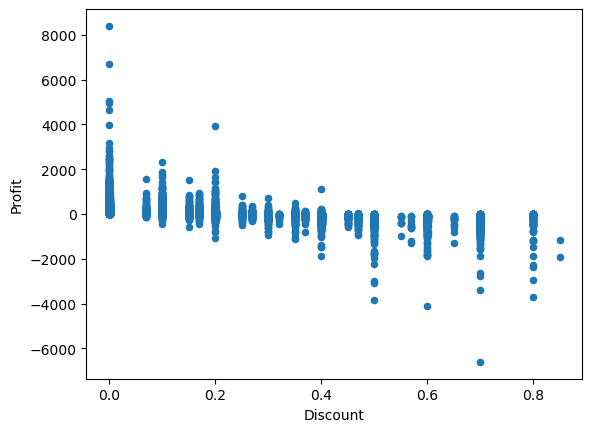

In [282]:
#create a scatter plot showing profit vs discount
orders.plot.scatter(x='Discount', y='Profit')

In [283]:
#check the average profit and sales made by each discount value
orders.groupby('Discount')[['Sales', 'Profit']].mean()

,Sales,Profit
Discount,,
0.000,241.042813,61.039514
0.002,567.018701,125.762649
0.070,810.779022,140.990022
0.100,388.300485,63.683426
0.150,618.474630,56.855240
0.150,270.121811,15.601811
0.170,336.597556,38.317107
0.200,240.862803,23.552594
0.202,395.503592,-14.518847


In [306]:
#check the net profit made by sub-category and discount
orders.groupby(['Sub-Category','Discount'])['Profit'].sum()

Sub-Category  Discount
Accessories   0.00        149217.1839
              0.10          9686.8290
              0.20          8122.3498
              0.40         -6182.9280
              0.45         -2195.8965
                             ...     
Tables        0.57         -6313.5480
              0.60        -10592.8320
              0.70        -34283.7910
              0.80         -7616.9020
              0.85         -3068.6580
Name: Profit, Length: 189, dtype: float64

In [308]:
#check the net profit made by each discount band and sub-category
orders.groupby(['Sub-Category','discount_band'])['Profit'].sum().unstack()

/var/folders/8s/h8cf9wn53d14dsbsfg_7r9zm0000gn/T/ipykernel_16133/752262574.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders.groupby(['Sub-Category','discount_band'])['Profit'].sum().unstack()


discount_band,0-10%,10-20%,20-30%,30-50%,50%+
Sub-Category,,,,,
Accessories,9686.82900,8122.3498,0.00000,-26605.39350,-10794.66300
Appliances,33154.28080,14678.1607,0.00000,-24068.05500,-34021.68320
Art,3346.17000,1518.1416,-596.53710,-8192.90820,-11649.14600
Binders,3012.35700,31493.8637,0.00000,-6684.37000,-45221.29540
Bookcases,57455.99940,7018.0017,-555.87260,-49116.31130,-40763.98940
Chairs,49143.10890,11166.5150,-6952.94150,-27040.17700,-38437.58400
Copiers,92327.22698,25743.5793,-595.27272,-34478.45482,-24866.74546
Envelopes,1592.35500,2333.4846,0.00000,-6793.81570,-3632.88200
Fasteners,1021.29900,561.2234,0.00000,-4363.16650,-1637.39700


In [ ]:
#check the total net profit made by orders within each discount band
orders.groupby('discount_band')['Profit'].sum()

In [287]:
#check the net profit made from orders in each discount bands by category
orders.groupby(['Category', 'discount_band'])['Profit'].sum()

/var/folders/8s/h8cf9wn53d14dsbsfg_7r9zm0000gn/T/ipykernel_16133/1991449517.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders.groupby(['Category', 'discount_bands'])['Profit'].sum()


Category         discount_bands
Furniture        0-10%             576974.30970
                 10-30%              8533.52780
                 30-50%           -140748.63510
                 50-70%           -148408.63460
                 70%+              -11145.84400
Office Supplies  0-10%             696811.98820
                 10-30%             58823.96020
                 30-50%           -105373.20550
                 50-70%           -101249.86940
                 70%+              -30539.03920
Technology       0-10%             835098.23668
                 10-30%             84741.74228
                 30-50%           -134822.97522
                 50-70%           -121238.27056
                 70%+                   0.00000
Name: Profit, dtype: float64

## 5.6. Loss Analysis

In [289]:
#check the total sales made in the dataset
orders['Sales'].sum()

np.float64(12642501.909880001)

In [69]:
#calculate the net profit by each category
orders.groupby('Category')['Profit'].sum()

Category
Furniture          285204.72380
Office Supplies    518473.83430
Technology         663778.73318
Name: Profit, dtype: float64

In [288]:
#calculate the sum of loss by unprofitable orders by category
orders[orders['Profit']<0].groupby('Category')['Profit'].sum()

Category
Furniture         -370168.83970
Office Supplies   -263981.91760
Technology        -286495.39842
Name: Profit, dtype: float64

In [290]:
#calculate total loss from unprofitable orders by sub-category and category
orders[orders['Profit']<0].groupby(['Sub-Category','Category'])['Profit'].sum().sort_values(ascending=False)

Sub-Category  Category       
Labels        Office Supplies     -3760.77010
Fasteners     Office Supplies     -6273.29990
Paper         Office Supplies    -10299.49370
Envelopes     Office Supplies    -10863.56550
Supplies      Office Supplies    -18184.43100
Art           Office Supplies    -21660.62770
Furnishings   Furniture          -28514.49690
Accessories   Technology         -39857.49820
Binders       Office Supplies    -52884.06130
Appliances    Office Supplies    -63991.69040
Copiers       Technology         -71547.49982
Storage       Office Supplies    -76063.97800
Machines      Technology         -78672.74030
Chairs        Furniture          -96084.89690
Phones        Technology         -96417.66010
Bookcases     Furniture         -101446.29730
Tables        Furniture         -144123.14860
Name: Profit, dtype: float64

## 5.7. Market-Level Profitability and Risk Analysis

In [293]:
#calculate the total loss by each market
orders[orders['Profit']<0].groupby('Market')['Profit'].sum().sort_values(ascending=False)

Market
Africa    -88875.03300
EMEA     -123065.91300
US       -156131.28570
LATAM    -165817.16412
EU       -186188.99550
APAC     -200567.76440
Name: Profit, dtype: float64

In [294]:
#calculate the net profit made by each market
orders.groupby('Market')['Profit'].sum().sort_values(ascending=False)

Market
APAC      436000.04900
EU        372829.74150
US        286397.02170
LATAM     221643.48708
Africa     88871.63100
EMEA       43897.97100
Canada     17817.39000
Name: Profit, dtype: float64

In [295]:
#calculate the total sales made by each market
orders.groupby('Market')['Sales'].sum().sort_values(ascending=False)

Market
APAC      3.585744e+06
EU        2.938089e+06
US        2.297201e+06
LATAM     2.164605e+06
EMEA      8.061613e+05
Africa    7.837732e+05
Canada    6.692817e+04
Name: Sales, dtype: float64

In [297]:
#summarise sales, net profit, loss, and loss percentage by market
sales=orders.groupby('Market')['Sales'].sum()
profit=orders.groupby('Market')['Profit'].sum()
loss=orders[orders['Profit']<0].groupby('Market')['Profit'].sum()
loss_ptg=(loss.abs()/sales)*100

loss_summary=pd.DataFrame({
    'Total Sales': sales, 
    'Total Profit': profit,
    'Profit Loss': loss,
    'Loss % of Sales': loss_ptg
})

loss_summary['Loss % of Sales']=loss_summary['Loss % of Sales'].round(2)
loss_summary

,Total Sales,Total Profit,Profit Loss,Loss % of Sales
Market,,,,
APAC,3.585744e+06,436000.04900,-200567.76440,5.59
Africa,7.837732e+05,88871.63100,-88875.03300,11.34
Canada,6.692817e+04,17817.39000,NaN,NaN
EMEA,8.061613e+05,43897.97100,-123065.91300,15.27
EU,2.938089e+06,372829.74150,-186188.99550,6.34
LATAM,2.164605e+06,221643.48708,-165817.16412,7.66
US,2.297201e+06,286397.02170,-156131.28570,6.80


## 5.8. Transaction-Level Profitability Analysis

In [298]:
#inspect the category, sub-category, discount, sales and profit of ten smallest profit orders
orders.nsmallest(10, 'Profit')[['Category','Sub-Category','Discount','Sales','Profit']]

,Category,Sub-Category,Discount,Sales,Profit
171,Technology,Machines,0.7,4499.985,-6599.9780
6591,Technology,Phones,0.6,3085.344,-4088.3760
37,Technology,Machines,0.5,7999.980,-3839.9904
1341,Office Supplies,Binders,0.8,2177.584,-3701.8928
2347,Technology,Machines,0.7,2549.985,-3399.9800
512,Office Supplies,Appliances,0.5,3399.660,-3059.8200
362,Technology,Phones,0.5,3499.155,-3009.4350
2101,Office Supplies,Binders,0.8,1889.990,-2929.4845
245,Furniture,Tables,0.7,2171.160,-2750.2800
859,Technology,Machines,0.7,1799.994,-2639.9912


In [299]:
#inspect the category, sub-category, discount, sales and profit of ten largest profit orders
orders.nlargest(10, 'Profit')[['Category','Sub-Category','Discount','Sales','Profit']]

,Category,Sub-Category,Discount,Sales,Profit
329,Technology,Copiers,0.0,17499.950,8399.9760
14843,Technology,Copiers,0.0,13999.960,6719.9808
290,Technology,Copiers,0.0,10499.970,5039.9856
122,Office Supplies,Binders,0.0,9892.740,4946.3700
45,Office Supplies,Binders,0.0,9449.950,4630.4755
17,Office Supplies,Appliances,0.0,7958.580,3979.0800
7399,Technology,Copiers,0.2,11199.968,3919.9888
76,Office Supplies,Binders,0.0,6354.950,3177.4750
215,Technology,Phones,0.0,6998.640,2939.3100
313,Technology,Phones,0.0,5751.540,2817.9900


## 6. Export Dataset for Dashboard

In [334]:
#extract the modified orders dataset to csv for use in dashboard
orders.to_csv('orders_dashboard_notebook_ver.csv', index=False)

# 7. Summary Findings and Recommendations 

## 7.1. Segment Performance and Profitability
The Consumer segment generates the highest sales, profit, and order volume, making it the main driver of business performance. However, it also records the highest total loss, around 477K, showing that its large transaction volume also creates greater exposure to unprofitable orders. Corporate contributes about 59% of Consumer sales and profit, with lower losses, making it a valuable secondary segment. Home-Office generates the lowest total sales and profit due to fewer orders, but it has the highest average profit per transaction and the lowest total loss, around 168K. Therefore, while Consumer should remain the main focus, Corporate and Home-Office should not be undervalued because they provide more stable profit contributions with lower loss exposure.


## 7.2. Market Performance and Efficiency
APAC is the strongest market, generating the highest sales and profit, despite having only slightly more orders than LATAM, EU, and US. This suggests that APAC is highly valuable and should remain a key market for maintaining and improving business performance. EU and US also perform strongly, ranking second and third in both sales and profit. In contrast, LATAM has the second-highest number of orders but ranks only fourth in sales and profit, suggesting lower revenue and profit efficiency per order. EMEA and Africa generate lower overall sales and profit, with EMEA performing weaker than Africa in profit despite slightly higher sales. Canada has the lowest order count and total sales, but its profit appears relatively strong compared with its sales volume, suggesting possible growth potential if market activity can be expanded carefully. Overall, APAC, EU, and US are the main performance drivers, while LATAM, EMEA, and Africa should be reviewed for possible pricing, cost, logistics, or market efficiency issues.


## 7.3. Shipping Mode Patterns
Across all markets, Standard Class is the dominant shipping mode, used by around 58%-61% of customers in most markets. Second Class accounts for around 19%-22%, First Class around 14%-15%, and Same Day only around 5%, showing that customers generally prefer cost-efficient shipping over faster delivery. Shipping behaviour is also linked to order priority: low-priority orders use only Standard Class, while critical orders avoid Standard Class and rely more on First Class, Second Class, and Same Day delivery. Canada is the main exception, with only around 51% using Standard Class and relatively higher use of Second Class, First Class, and Same Day. However, because Canada has a very small order count, this pattern should be interpreted carefully before making expansion decisions.

## 7.4. Category Profitability
Office Supplies records the highest number of transactions, but generates the lowest total sales, which may indicate lower-value or lower-priced items. Despite this, it produces a strong total profit and has the lowest total loss, suggesting relatively stable profitability. Technology has the lowest number of loss-making transactions but generates the highest sales and profit, making it the strongest revenue and profit driver among the three categories. In contrast, Furniture generates the second-highest sales but the lowest profit and the highest total loss. This shows that Furniture is less efficient at converting sales into profit and may be affected by high costs, discounting, pricing issues, or logistics-related expenses. Therefore, Furniture should be investigated further as the main category contributing to profit erosion.


## 7.5. Discount Impact on Profitability
Discounting has a clear impact on profitability. Non-discounted orders generate the strongest performance, contributing around €7.0M in sales and €1.77M in profit. Low discounts between 0% and 20% generally remain profitable, especially 10% and 20% discounts, which still generate strong sales and positive profit. However, losses begin to appear after this point and become more consistent from around 27%-30% onwards. Higher discount levels such as 40%, 50%, 60%, and 70% create substantial losses despite generating sales, showing that aggressive discounting is eroding profit margins. Although non-discounted orders alone generate approximately €1.77M in profit, the overall net profit across all orders decreases to approximately €1.47M after discounted and loss-making transactions are included. Nevertheless, the loss-making orders accounting for around -€0.92M indicates that discount controls should be strengthened, especially for discounts above 30%.


## 7.6. Category-Level Discount Performance
Across all categories, the 0-10% discount band generates the highest profit, with Technology contributing around €835K, Office Supplies around €697K, and Furniture around €577K. The 10-30% discount band remains profitable, but profit drops sharply across all categories. Once discounts exceed 30%, all categories move into negative profit, showing that higher discounting consistently erodes margins rather than improving profitability. Furniture is the most affected category, recording the largest losses in the 30-70% discount range, which suggests that it may have thinner margins, higher costs, or weaker pricing resilience. Therefore, products discounted above 30%, especially within Furniture, should be reviewed to identify whether the current discount strategy is financially sustainable in the long-term.


## 7.7. Sub-Category Loss Drivers
Sub-category analysis shows that losses are concentrated in a small number of product groups rather than being evenly spread across all products. The largest loss contributors are Tables (-€144K), Bookcases (-€101K), Phones (-€96K), Chairs (-€96K), Machines (-€79K), and Storage (-€76K). Three of these major loss-driving sub-categories belong to Furniture, even though Furniture has only four sub-categories, reinforcing that Furniture is the category most affected by profit erosion. Office Supplies has the highest number of sub-categories, but its losses are more spread out and generally smaller. Technology remains profitable overall, but all four Technology sub-categories still record some losses, showing that loss-making transactions also exist within  strong-performing categories. Overall, this suggests that pricing and discount strategies should be reviewed at sub-category level, especially for Furniture products such as Tables, Bookcases, and Chairs.


## 7.8. Market Profitability Risk
APAC and EU are the strongest markets in performance, generating the highest sales and profits while keeping losses relatively controlled at 5.59% and 6.34% of sales. The US and LATAM also remain profitable, but with slightly higher loss ratios of 6.80% and 7.66%. In contrast, EMEA and Africa show greater profitability risk, with losses accounting for 15.27% and 11.34% of sales respectively. This suggests that although these markets remain profitable overall, they are less efficient and more exposed to margin erosion. Canada records no losses, but its impact is limited because of its very small sales volume. Overall, APAC and EU are the main profit drivers, while EMEA and Africa should be reviewed for pricing, discounting, or operational inefficiencies.


## 7.9. Transaction-Level Profitability
The top 10 loss-making transactions are all associated with high discounts of 50%-80%, showing that extreme discounting leads to severe profit erosion even when sales values are high. In contrast, the top 10 profit-generating transactions mostly have no discount, with only one transaction using a moderate 20% discount. These profitable transactions are mainly from Technology and Office Supplies, while Furniture does not appear among the top profit-generating transactions. This supports the earlier finding that aggressive discounting, especially above 50%, should be reviewed because it increases losses rather than improving profitability.
